# Rebar Market Intelligence: Construction Spending & Rebar Price Analysis

## Project Overview
This analysis examines the historical relationship between U.S. construction spending and rebar prices using monthly data from January 1993 through July 2026.
The objective is to determine whether changes in construction spending are associated with changes in rebar prices and whether construction activity can serve as a useful market indicator for the rebar industry.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
import os
os.getcwd()

'/Users/tlewis1/Downloads/rebar market analysis/python'

In [15]:
import os
os.getcwd()

'/Users/tlewis1/Downloads/rebar market analysis/python'

In [20]:
os.listdir("../")

['documentation', '.DS_Store', 'python', 'README', 'mySQL', 'visuals', 'data']

In [21]:
os.listdir("../data")

['.DS_Store',
 'Rebar Market Intelligience - Analysis Ready - Analysis_Data_2.csv',
 'Raw Data']

In [22]:
df = pd.read_csv("../data/Rebar Market Intelligience - Analysis Ready - Analysis_Data_2.csv")

In [23]:
df.head()

,Date,Total_Construction,Rebar_PPI
0,1/1/1993,"31,283",116.5
1,2/1/1993,"30,264",117.4
2,3/1/1993,"33,794",117.6
3,4/1/1993,"37,257",117.4
4,5/1/1993,"40,124",118.5


In [24]:
print("Shape:", df.shape)
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Columns:", df.columns.tolist())

Shape: (403, 3)
Start date: 1/1/1993
End date: 9/1/2025
Columns: ['Date', 'Total_Construction', 'Rebar_PPI']


In [26]:
df["Date"] = pd.to_datetime(df["Date"])

In [27]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 1993-01-01 00:00:00
End date: 2026-07-01 00:00:00


In [28]:
df.isna().sum()

Date                  0
Total_Construction    0
Rebar_PPI             0
dtype: int64

In [30]:
df["Total_Construction"] = (
    df["Total_Construction"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [31]:
df["Construction_Change"] = df["Total_Construction"].pct_change() * 100
df["Rebar_Change"] = df["Rebar_PPI"].pct_change() * 100

In [32]:
df.head()

,Date,Total_Construction,Rebar_PPI,Construction_Change,Rebar_Change
0,1993-01-01,31283.0,116.5,NaN,NaN
1,1993-02-01,30264.0,117.4,-3.257360,0.772532
2,1993-03-01,33794.0,117.6,11.664023,0.170358
3,1993-04-01,37257.0,117.4,10.247381,-0.170068
4,1993-05-01,40124.0,118.5,7.695198,0.936968


In [33]:
df.dtypes

Date                   datetime64[ns]
Total_Construction            float64
Rebar_PPI                     float64
Construction_Change           float64
Rebar_Change                  float64
dtype: object

## BQ1 — How has total U.S. construction spending changed over the period analyzed?

In [34]:
df[["Date", "Total_Construction"]].head()

,Date,Total_Construction
0,1993-01-01,31283.0
1,1993-02-01,30264.0
2,1993-03-01,33794.0
3,1993-04-01,37257.0
4,1993-05-01,40124.0


In [35]:
start_construction = df["Total_Construction"].iloc[0]
end_construction = df["Total_Construction"].iloc[-1]

absolute_change = end_construction - start_construction
percent_change = (absolute_change / start_construction) * 100

print("Starting construction spending:", start_construction)
print("Ending construction spending:", end_construction)
print("Absolute change:", absolute_change)
print("Percent change:", percent_change)

Starting construction spending: 31283.0
Ending construction spending: 197271.0
Absolute change: 165988.0
Percent change: 530.6012850429946


### BQ1 Visualization

The chart below shows the long-term trend in total U.S. construction spending from January 1993 through July 2026.

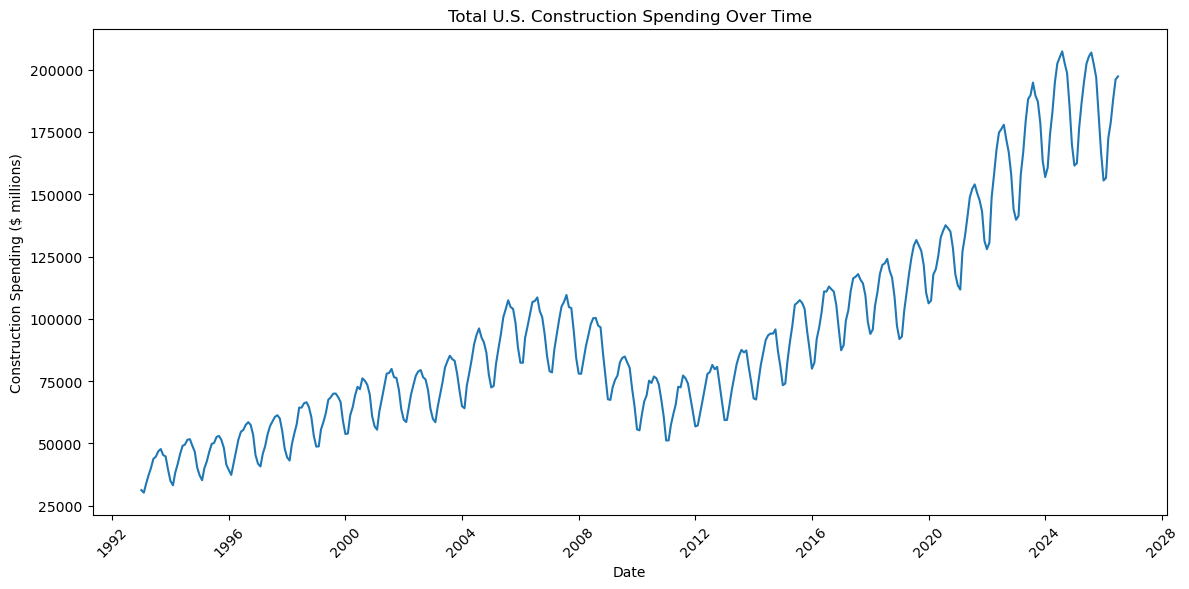

In [51]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Total_Construction"])

plt.title("Total U.S. Construction Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Construction Spending ($ millions)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### BQ1 Interpretation

Total U.S. construction spending increased substantially over the analysis period. Monthly construction spending rose from $31,283 million in January 1993 to $197,271 million in July 2026, representing an absolute increase of $165,988 million, or approximately 530.60%.

This indicates significant long-term growth in construction spending over the period analyzed. However, this overall increase does not indicate that construction spending increased every month, nor does it establish a relationship with rebar prices.

## BQ2 — How have rebar prices changed over the period analyzed?

In [52]:
start_rebar = df["Rebar_PPI"].iloc[0]
end_rebar = df["Rebar_PPI"].iloc[-1]

absolute_change = end_rebar - start_rebar
percent_change = (absolute_change / start_rebar) * 100

print("Starting rebar PPI:", start_rebar)
print("Ending rebar PPI:", end_rebar)
print("Absolute change:", absolute_change)
print("Percent change:", percent_change)

Starting rebar PPI: 116.5
Ending rebar PPI: 373.472
Absolute change: 256.972
Percent change: 220.57682403433475


### BQ2 Visualization

The chart below shows the long-term trend in the Rebar Producer Price Index (PPI) from January 1993 through July 2026.

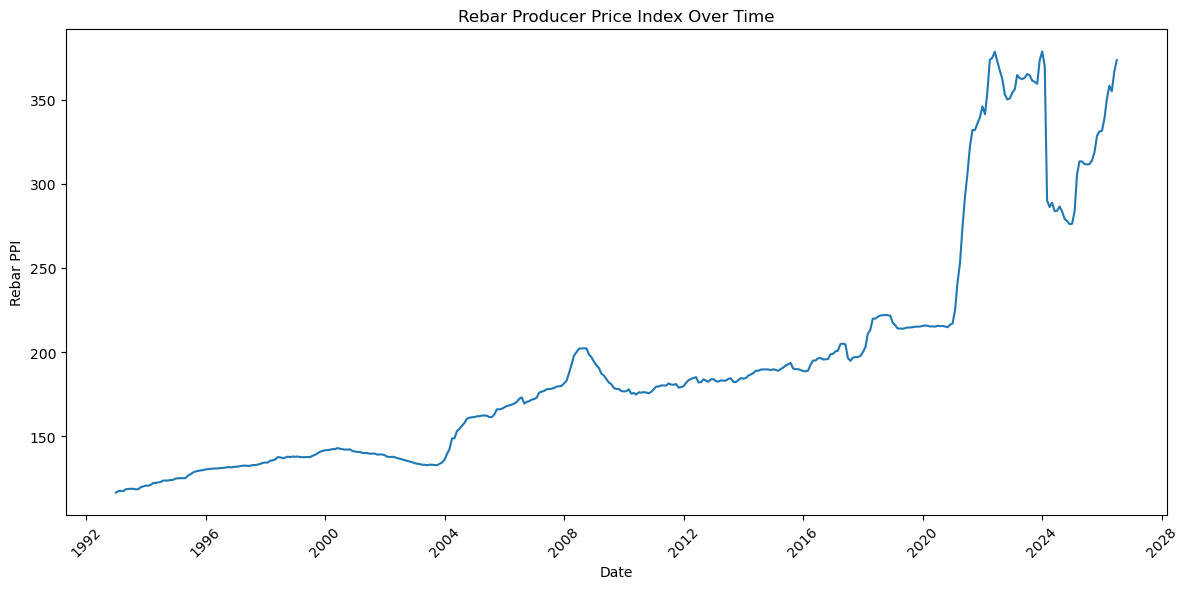

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Rebar_PPI"])

plt.title("Rebar Producer Price Index Over Time")
plt.xlabel("Date")
plt.ylabel("Rebar PPI")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### BQ2 Interpretation

Rebar prices increased substantially over the analysis period. The Rebar PPI rose from 116.5 in January 1993 to 373.472 in July 2026, an increase of 256.972 index points, or approximately 220.58%.

This indicates a significant long-term increase in the producer price index for fabricated structural metal bar joists and concrete reinforcing bars. However, the long-term increase in rebar prices does not by itself establish that construction spending caused the change.

## BQ3 — Is there a measurable relationship between total construction spending and rebar prices?

In [54]:
correlation = df["Total_Construction"].corr(df["Rebar_PPI"])

print("Correlation coefficient:", correlation)

Correlation coefficient: 0.9020380743033682


### BQ3 Visualization

The scatter plot below shows the relationship between total U.S. construction spending and the Rebar Producer Price Index. Each point represents one month in the analysis period. The trendline illustrates the direction of the linear relationship, while the R² value indicates how much of the variation in rebar PPI is explained by the linear relationship with construction spending.

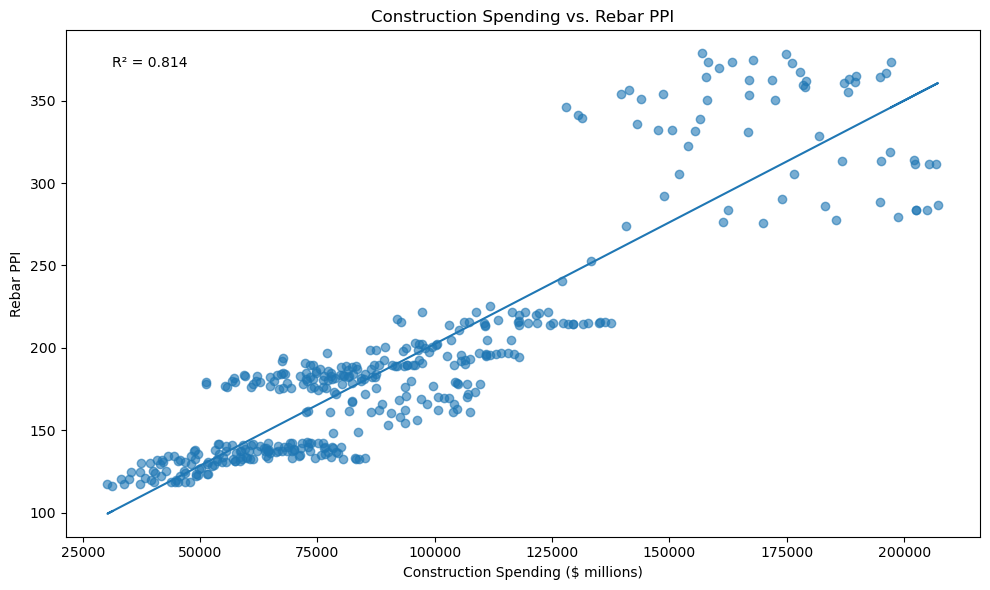

In [58]:
# Calculate linear regression
x = df["Total_Construction"]
y = df["Rebar_PPI"]

slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

# Calculate R²
correlation = x.corr(y)
r_squared = correlation ** 2

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.6)
plt.plot(x, trendline)

plt.title("Construction Spending vs. Rebar PPI")
plt.xlabel("Construction Spending ($ millions)")
plt.ylabel("Rebar PPI")

plt.text(
    0.05,
    0.95,
    f"R² = {r_squared:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

### BQ3 Interpretation

The correlation coefficient between total U.S. construction spending and rebar prices is approximately 0.902. This indicates a very strong positive linear relationship between the two variables over the analysis period.

In general, higher levels of construction spending are associated with higher levels of the rebar PPI. However, correlation does not establish causation. The strong relationship may also reflect broader long-term changes in the construction market and price levels over the period analyzed.

This result measures the relationship between the overall levels of the two variables. It does not measure whether month-to-month changes in construction spending are associated with month-to-month changes in rebar prices, which will be examined in the next business question.

## BQ4 — How strong is the relationship between changes in construction spending and changes in rebar prices?

In [59]:
change_correlation = df["Construction_Change"].corr(df["Rebar_Change"])

print("Correlation between monthly changes:", change_correlation)

Correlation between monthly changes: 0.09088121863474562


### BQ4 Visualization

The scatter plot below compares monthly percentage changes in total construction spending with monthly percentage changes in rebar prices. The trendline shows the direction of the linear relationship, while the R² value indicates how much of the variation in monthly rebar price changes is explained by monthly construction spending changes.

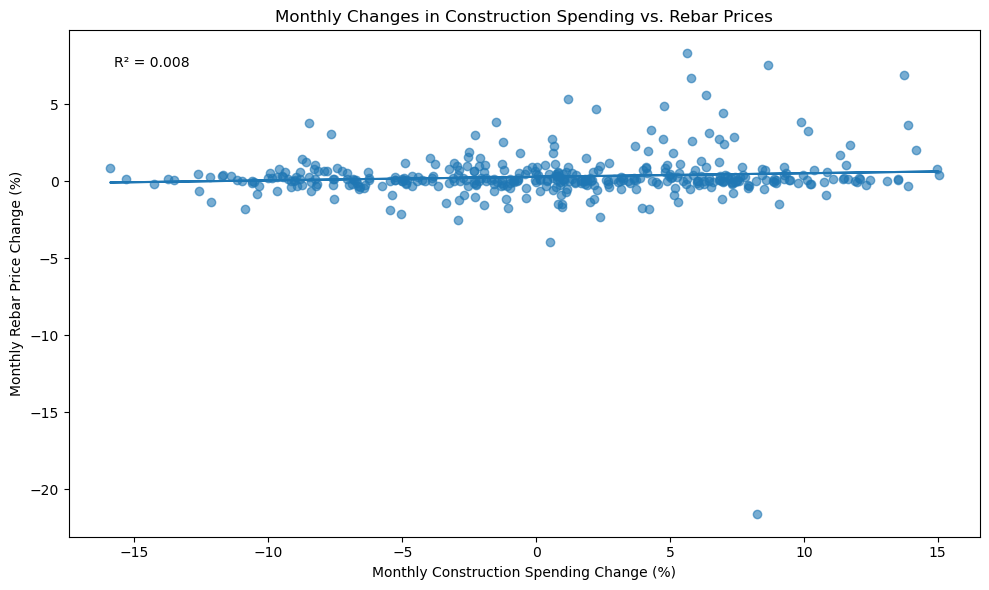

In [61]:
# Calculate linear regression
x = df["Construction_Change"]
y = df["Rebar_Change"]

# Remove missing values from the first month
valid = x.notna() & y.notna()
x = x[valid]
y = y[valid]

slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

# Calculate R²
correlation = x.corr(y)
r_squared = correlation ** 2

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.6)
plt.plot(x, trendline)

plt.title("Monthly Changes in Construction Spending vs. Rebar Prices")
plt.xlabel("Monthly Construction Spending Change (%)")
plt.ylabel("Monthly Rebar Price Change (%)")

plt.text(
    0.05,
    0.95,
    f"R² = {r_squared:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

### BQ4 Interpretation

The correlation between monthly changes in total construction spending and monthly changes in rebar prices is approximately 0.091. This indicates a very weak positive relationship between the month-to-month movements of the two variables.

Although the overall levels of construction spending and rebar prices have a strong positive relationship, their monthly changes do not move closely together. This suggests that short-term changes in construction spending alone are not a strong indicator of monthly rebar price movements.

This result also demonstrates the importance of distinguishing between long-term trends in the levels of two variables and their short-term changes.

## BQ5 — Do changes in construction spending tend to occur before, after, or at the same time as changes in rebar prices?

In [62]:
same_month = df["Construction_Change"].corr(df["Rebar_Change"])

construction_leads = df["Construction_Change"].corr(df["Rebar_Change"].shift(-1))

rebar_leads = df["Construction_Change"].corr(df["Rebar_Change"].shift(1))

print("Same-month correlation:", same_month)
print("Construction spending leads rebar by 1 month:", construction_leads)
print("Rebar prices lead construction spending by 1 month:", rebar_leads)

Same-month correlation: 0.09088121863474562
Construction spending leads rebar by 1 month: 0.05940936564136395
Rebar prices lead construction spending by 1 month: 0.08684245463333391


### BQ5 Visualization

The chart below compares the correlation between monthly construction spending changes and rebar price changes under three timing scenarios: the same month, construction spending leading by one month, and rebar prices leading by one month.

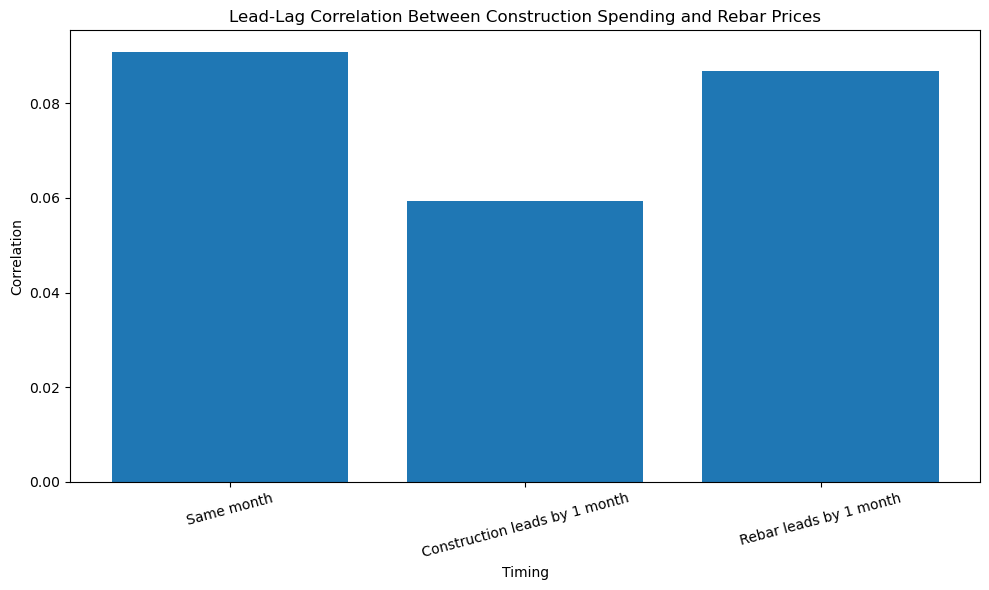

In [63]:
# Create lead-lag correlation results
lead_lag = pd.DataFrame({
    "Timing": [
        "Same month",
        "Construction leads by 1 month",
        "Rebar leads by 1 month"
    ],
    "Correlation": [
        same_month,
        construction_leads,
        rebar_leads
    ]
})

plt.figure(figsize=(10, 6))

plt.bar(
    lead_lag["Timing"],
    lead_lag["Correlation"]
)

plt.title("Lead-Lag Correlation Between Construction Spending and Rebar Prices")
plt.xlabel("Timing")
plt.ylabel("Correlation")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### BQ5 Interpretation

The timing analysis shows very weak relationships in all three scenarios. The same-month correlation is approximately 0.091, while the correlation when construction spending leads rebar prices by one month is approximately 0.059. When rebar prices lead construction spending by one month, the correlation is approximately 0.087.

The strongest of the three relationships is the one-month rebar-leading correlation, but it remains very weak. Therefore, the analysis does not provide strong evidence that either construction spending or rebar prices consistently lead the other on a one-month basis.

Overall, the results suggest that month-to-month movements in these variables do not follow a strong or consistent lead-lag pattern.

## BQ6 — Does the relationship change when construction spending increases versus decreases?

In [64]:
increasing = df[df["Construction_Change"] > 0]
decreasing = df[df["Construction_Change"] < 0]

increasing_correlation = increasing["Construction_Change"].corr(
    increasing["Rebar_Change"]
)

decreasing_correlation = decreasing["Construction_Change"].corr(
    decreasing["Rebar_Change"]
)

print("Correlation when construction spending increases:", increasing_correlation)
print("Correlation when construction spending decreases:", decreasing_correlation)


Correlation when construction spending increases: 0.06798110316479444
Correlation when construction spending decreases: 0.04409762397146008


### BQ6 Visualization

The chart below compares the correlation between monthly construction spending changes and rebar price changes during periods when construction spending increased versus periods when construction spending decreased.

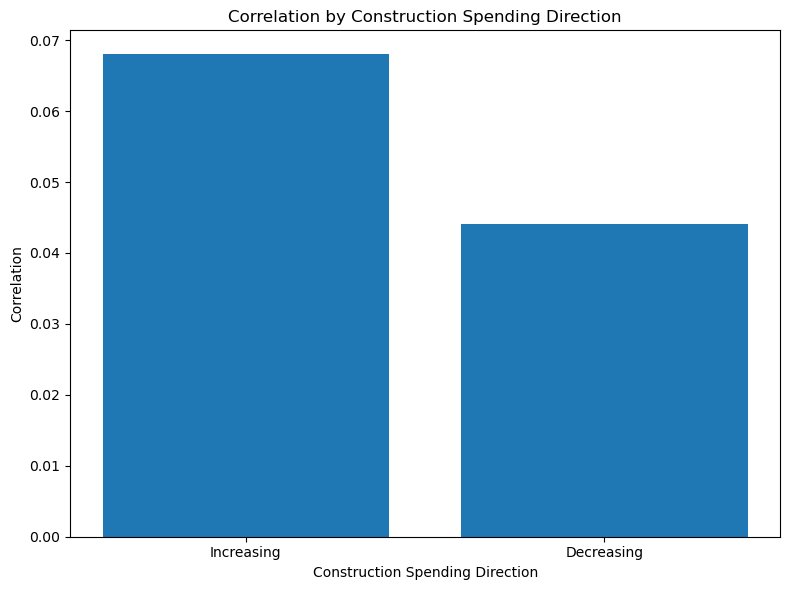

In [66]:
# Create increasing vs. decreasing correlation results
directional = pd.DataFrame({
    "Construction Direction": [
        "Increasing",
        "Decreasing"
    ],
    "Correlation": [
        increasing_correlation,
        decreasing_correlation
    ]
})

plt.figure(figsize=(8, 6))

plt.bar(
    directional["Construction Direction"],
    directional["Correlation"]
)

plt.title("Correlation by Construction Spending Direction")
plt.xlabel("Construction Spending Direction")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

### BQ6 Interpretation

The correlation between monthly construction spending changes and rebar price changes is approximately 0.068 when construction spending increases and approximately 0.044 when construction spending decreases.

The relationship is slightly stronger during periods of increasing construction spending. However, both correlations remain very weak, indicating that the direction of construction spending does not substantially change the relationship with monthly rebar price movements.

Overall, whether construction spending is increasing or decreasing, monthly changes in construction spending alone do not appear to be a strong indicator of monthly changes in rebar prices.

## BQ7 — What historical periods show significant changes in both construction spending and rebar prices, and what patterns are observed?

In [67]:
construction_threshold = df["Construction_Change"].abs().quantile(0.90)
rebar_threshold = df["Rebar_Change"].abs().quantile(0.90)

significant_periods = df[
    (df["Construction_Change"].abs() >= construction_threshold) &
    (df["Rebar_Change"].abs() >= rebar_threshold)
][[
    "Date",
    "Total_Construction",
    "Rebar_PPI",
    "Construction_Change",
    "Rebar_Change"
]]

print("Construction change threshold:", construction_threshold)
print("Rebar change threshold:", rebar_threshold)
print()
print(significant_periods.to_string(index=False))

Construction change threshold: 10.620136113163499
Rebar change threshold: 1.822707074815752

      Date  Total_Construction  Rebar_PPI  Construction_Change  Rebar_Change
2004-03-01             73238.0    142.400            14.188157      2.005731
2008-11-01             86093.0    198.500           -10.885114     -1.829871
2021-03-01            127095.0    240.900            13.753938      6.876664
2022-03-01            148686.0    353.839            13.902465      3.670553
2023-03-01            157866.0    364.557            11.737435      2.341270


### BQ7 Visualization

The chart below compares the monthly percentage changes in construction spending and rebar prices during the five periods identified as having significant movements in both variables.

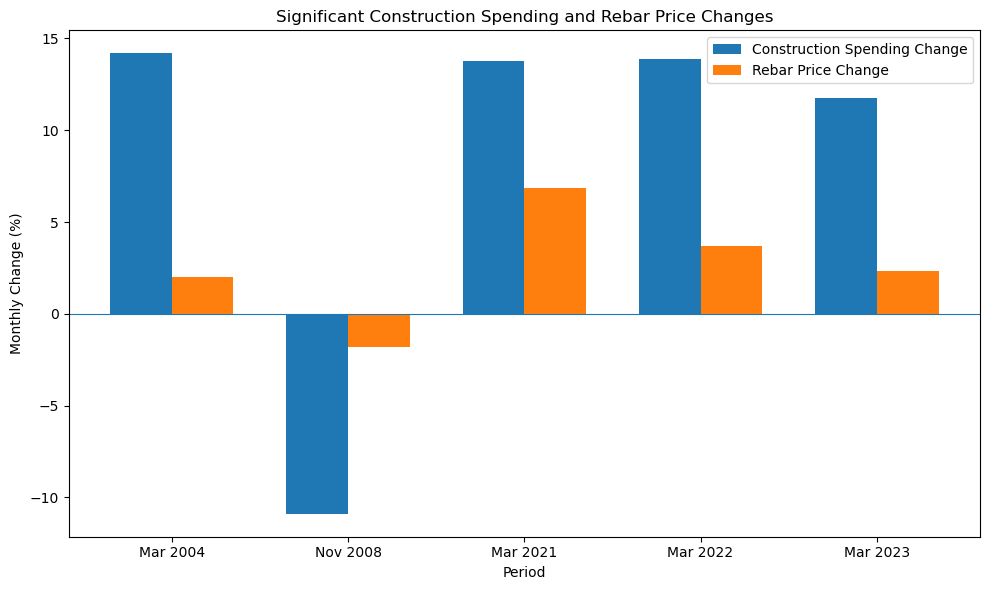

In [72]:
# Prepare significant periods for visualization
bq7_visual = significant_periods.copy()

bq7_visual["Date"] = bq7_visual["Date"].dt.strftime("%b %Y")

plt.figure(figsize=(10, 6))

x = np.arange(len(bq7_visual))
width = 0.35

plt.bar(
    x - width / 2,
    bq7_visual["Construction_Change"],
    width,
    label="Construction Spending Change"
)

plt.bar(
    x + width / 2,
    bq7_visual["Rebar_Change"],
    width,
    label="Rebar Price Change"
)

plt.axhline(0, linewidth=0.8)

plt.title("Significant Construction Spending and Rebar Price Changes")
plt.xlabel("Period")
plt.ylabel("Monthly Change (%)")
plt.xticks(x, bq7_visual["Date"])

plt.legend()

plt.tight_layout()
plt.show()

### BQ7 Interpretation

Using the 90th percentile of the absolute monthly changes as the threshold for significant movements, five periods showed unusually large changes in both construction spending and rebar prices.

Four of the five significant periods had increases in both construction spending and rebar prices: March 2004, March 2021, March 2022, and March 2023. November 2008 was the only identified period where both variables experienced significant decreases.

These periods show that large movements in construction spending and rebar prices can occur in the same direction during certain market periods. However, the limited number of significant periods and the weak monthly correlations found in the earlier analysis indicate that this pattern is not consistent enough to establish a strong short-term relationship.

## BQ8 — What does the historical relationship indicate about the usefulness of construction activity as a market indicator for the rebar industry?

In [73]:
print("Level correlation:", df["Total_Construction"].corr(df["Rebar_PPI"]))
print("Monthly change correlation:", df["Construction_Change"].corr(df["Rebar_Change"]))
print("Construction leads rebar by 1 month:",
      df["Construction_Change"].corr(df["Rebar_Change"].shift(-1)))
print("Rebar leads construction by 1 month:",
      df["Construction_Change"].corr(df["Rebar_Change"].shift(1)))

print("\nIncreasing construction correlation:",
      increasing["Construction_Change"].corr(increasing["Rebar_Change"]))
print("Decreasing construction correlation:",
      decreasing["Construction_Change"].corr(decreasing["Rebar_Change"]))

Level correlation: 0.9020380743033682
Monthly change correlation: 0.09088121863474562
Construction leads rebar by 1 month: 0.05940936564136395
Rebar leads construction by 1 month: 0.08684245463333391

Increasing construction correlation: 0.06798110316479444
Decreasing construction correlation: 0.04409762397146008


### BQ8 Visualization

The chart below summarizes the correlation results from the analysis to show how the relationship changes when comparing overall levels, monthly changes, lead-lag relationships, and periods of increasing or decreasing construction spending.

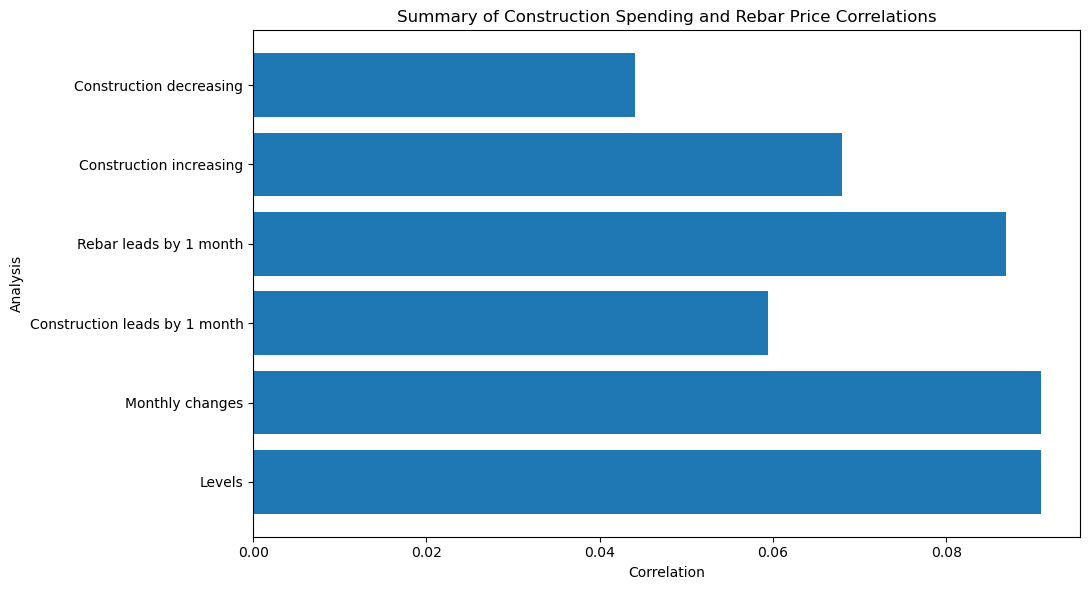

In [75]:
# Create summary of key correlation results
correlation_summary = pd.DataFrame({
    "Analysis": [
        "Levels",
        "Monthly changes",
        "Construction leads by 1 month",
        "Rebar leads by 1 month",
        "Construction increasing",
        "Construction decreasing"
    ],
    "Correlation": [
        correlation,
        change_correlation,
        construction_leads,
        rebar_leads,
        increasing_correlation,
        decreasing_correlation
    ]
})

plt.figure(figsize=(11, 6))

plt.barh(
    correlation_summary["Analysis"],
    correlation_summary["Correlation"]
)

plt.title("Summary of Construction Spending and Rebar Price Correlations")
plt.xlabel("Correlation")
plt.ylabel("Analysis")

plt.tight_layout()
plt.show()

### BQ8 Interpretation

The analysis indicates that construction activity is useful as a broad indicator of long-term conditions in the rebar market, but it is not a strong short-term predictor of rebar price movements.

The correlation between the levels of construction spending and rebar PPI is very strong at approximately 0.902. However, the correlation between their monthly changes is only approximately 0.091. The one-month lead-lag correlations are also very weak, at approximately 0.059 when construction spending leads rebar prices and 0.087 when rebar prices lead construction spending.

The relationship remains weak when separating periods of increasing and decreasing construction spending, with correlations of approximately 0.068 and 0.044, respectively.

Overall, construction spending can provide useful context for understanding broader long-term rebar market conditions, but construction spending alone should not be relied upon to predict short-term rebar price movements. Other market factors should be considered when evaluating rebar pricing.

# Final Findings and Conclusion

## Key Findings

- Total U.S. construction spending increased approximately 530.60% from January 1993 to July 2026.
- The Rebar PPI increased approximately 220.58% over the same period.
- Construction spending and rebar PPI have a strong positive correlation in their overall levels (0.902).
- The correlation between monthly changes is much weaker (0.091).
- One-month lead-lag relationships are also weak, with correlations of 0.059 when construction spending leads and 0.087 when rebar prices lead.
- The relationship remains weak when construction spending is separated into increasing (0.068) and decreasing (0.044) periods.
- Five significant periods showed large movements in both construction spending and rebar prices, with four moving upward and one moving downward.

## Overall Conclusion

The analysis indicates that construction spending is useful as a broad indicator of long-term conditions in the rebar market, but it is not a strong short-term predictor of rebar price movements.

The strong correlation between the overall levels of construction spending and rebar PPI suggests that both variables have followed similar long-term upward trends. However, the much weaker correlation between monthly changes indicates that short-term movements in construction spending alone do not explain changes in rebar prices well.

The lead-lag analysis also provides little evidence of a consistent one-month timing relationship, and separating periods of increasing and decreasing construction spending does not materially strengthen the relationship.

Overall, construction spending can provide valuable market context for the rebar industry, but it should be considered alongside other factors such as material costs, supply conditions, imports and exports, tariffs, energy prices, interest rates, and broader economic conditions when evaluating rebar pricing.